## Step 1

In [30]:
import cv2, numpy as np
import matplotlib.pyplot as plt
plt.gray()

L = cv2.imread("nose_left.png",  cv2.IMREAD_GRAYSCALE)
R = cv2.imread("nose_right.png", cv2.IMREAD_GRAYSCALE)

def sad(imgA: np.ndarray, imgB: np.ndarray) -> float:
    """Sum of absolute differences for two same-size arrays."""
    assert imgA.shape == imgB.shape, "Inputs must be same size"
    return float(np.abs(imgA.astype(np.int32) - imgB.astype(np.int32)).sum())

print("SAD(nose_left, nose_right) =", sad(L, R))


SAD(nose_left, nose_right) = 7657.0


<Figure size 640x480 with 0 Axes>

## Step 2

In [31]:
cand1 = cv2.imread("nose1.png", cv2.IMREAD_GRAYSCALE)
cand2 = cv2.imread("nose2.png", cv2.IMREAD_GRAYSCALE)
cand3 = cv2.imread("nose3.png", cv2.IMREAD_GRAYSCALE)

cands = [("nose1", cand1), ("nose2", cand2), ("nose3", cand3)]

scores = [(name, sad(L, img)) for name, img in cands]
scores_sorted = sorted(scores, key=lambda x: x[1])
print("SAD scores:", scores_sorted)
print("Best match:", scores_sorted[0][0])


SAD scores: [('nose2', 119.0), ('nose1', 1361.0), ('nose3', 1490.0)]
Best match: nose2


## Step 3

Best location in span: x=132, SAD=119


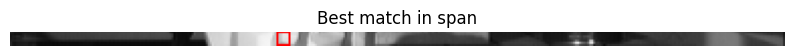

In [32]:
tpl  = cv2.imread("nose_left.png",  cv2.IMREAD_GRAYSCALE)     
span = cv2.imread("nose_span.png", cv2.IMREAD_GRAYSCALE)      

h, w = tpl.shape
H, W = span.shape
assert h == 7 and H == 7, f"Expected height 7, got tpl={h}, span={H}"

best_x = 0
best_cost = 10**12

x = 0
while x <= W - w:
    patch = span[:, x:x+w]
    cost = int(np.abs(tpl.astype(np.int32) - patch.astype(np.int32)).sum())  # SAD
    if cost < best_cost:
        best_cost = cost
        best_x = x
    x += 1

print(f"Best location in span: x={best_x}, SAD={best_cost}")

# visualize the match on the span
vis = np.dstack([span, span, span])
cv2.rectangle(vis, (best_x, 0), (best_x + w - 1, h - 1), (255, 0, 0), 1)
plt.figure(figsize=(10,2))
plt.imshow(vis); plt.axis('off'); plt.title("Best match in span")
plt.show()


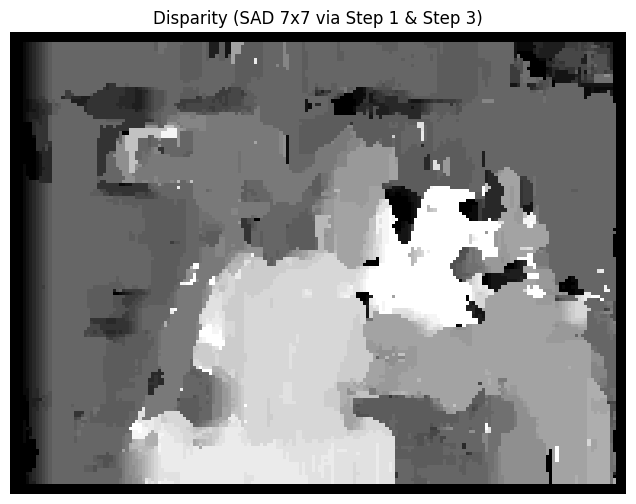

In [33]:
# --- Step 1: SAD ---
def sad(a, b):
    a = a.astype(np.int32)
    b = b.astype(np.int32)
    return int(np.abs(a - b).sum())

# --- Step 3: slide 7x7 template across a 7xW span (returns best offset from span start) ---
def slide_sad_1d(span_7xh, tpl_7x7):
    h, w = tpl_7x7.shape
    H, W = span_7xh.shape
    best_x, best_cost = 0, 1 << 60
    x = 0
    while x <= W - w:
        patch = span_7xh[:, x:x+w]
        cost = sad(tpl_7x7, patch)
        if cost < best_cost:
            best_cost, best_x = cost, x
        x += 1
    return best_x, best_cost

# --- load images (grayscale) ---
L = cv2.imread("tsukuba_left.png",  cv2.IMREAD_GRAYSCALE)
R = cv2.imread("tsukuba_right.png", cv2.IMREAD_GRAYSCALE)

# optional speed-up
scale = 0.5
L = cv2.resize(L, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)
R = cv2.resize(R, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

# --- disparity using only Step 1 + Step 3 ---
win = 7
r = win // 2
max_disp = 25
H, W = L.shape
disp = np.zeros((H, W), np.float32)

for y in range(r, H - r):
    for x in range(r, W - r):
        tpl = L[y-r:y+r+1, x-r:x+r+1]  # 7x7 from left

        # build 7xW span from the right image along the same row
        xr_left_min = max(0, x - r - max_disp)
        xr_left_max = min(x - r, W - win)
        if xr_left_min > xr_left_max:
            continue  # no valid search region at this x

        span = R[y-r:y+r+1, xr_left_min : xr_left_max + win]  # 7 x (something)

        off, _ = slide_sad_1d(span, tpl)                      # Step 3
        xr_left_match = xr_left_min + off                     # matched left-edge in right
        disp[y, x] = (x - r) - xr_left_match                  # disparity in pixels

plt.figure(figsize=(8,6))
plt.imshow(disp)
plt.axis('off')
plt.title("Disparity (SAD 7x7 via Step 1 & Step 3)")
plt.show()
